In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Loading the cleaned 50k balanced sample
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/yelp_NLP/reviews_balanced_50k.csv')
print(f"Loaded {len(df):,} reviews")
print(df['sentiment'].value_counts())
df.head(3)

Loaded 50,000 reviews
sentiment
positive    20000
negative    15000
neutral     15000
Name: count, dtype: int64


,review_id,stars,sentiment,text,clean_text,date,text_length
0,RsWi0oWuQ1bQUYNDOtRLIw,1.0,negative,Went there for a simple oil change and quote o...,went there for a simple oil change and quote o...,2013-09-10 23:02:32,687
1,8dky52oLmIS1fchbSlg5KA,5.0,positive,"Food was so good. Spinach salad, calzone and ...","food was so good. spinach salad, calzone and p...",2015-09-29 02:56:36,185
2,J-kQ4WwNkNWlajgqRdmChQ,5.0,positive,We've been frequenting this place pretty much ...,weve been frequenting this place pretty much s...,2017-08-30 19:34:56,262


Encode labels as integers for modeling

In [8]:
# Converting string sentiment labels to integers that models expect
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

df['label'] = df['sentiment'].map(label2id)
print(df[['sentiment', 'label']].drop_duplicates().sort_values('label'))

  sentiment  label
0  negative      0
4   neutral      1
1  positive      2


Train test split, stratified to preserve class balance.
Stratify ensures same distribution of label classes across train and test set.

In [9]:
# Stratified split so all three sentiment classes are proportionally represented in train and test
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Train size: {len(train_df):,}")
print(f"Test size:  {len(test_df):,}")
print(f"\nTrain sentiment distribution:\n{train_df['sentiment'].value_counts()}")

Train size: 40,000
Test size:  10,000

Train sentiment distribution:
sentiment
positive    16000
neutral     12000
negative    12000
Name: count, dtype: int64


Part A : Zero-shot classification with BART.

Meta Platforms developed BART (Bidirectional and Auto-Regressive Transformers), a transformer-based NLP model used for tasks like:

Text summarization
Question answering
Text generation
Translation

BART combines ideas from:

BERT → bidirectional understanding of text
BERT (Bidirectional Encoder Representations from Transformers) is a groundbreaking deep-learning model released by Google in 2018 that revolutionized Natural Language Processing (NLP). It is unique because it analyzes text in both directions simultaneously, allowing it to understand the context of a word based on the words immediately preceding and following it# Zero-shot approach: BART classifies reviews without any training on our data
GPT → autoregressive text generation

Primary Function: BERT is an "encoder-only" model built to read and comprehend. BART is an "encoder-decoder" (sequence-to-sequence) model built to read an input and generate a new output.

Architecture: BERT takes a sentence, looks at all the words simultaneously (bidirectionally), and maps them into numerical representations. BART uses a bidirectional encoder (like BERT) to understand the text, and an autoregressive decoder (like GPT) to write out new text based on that understanding.

The model is trained by corrupting text (masking, deleting, shuffling) and learning to reconstruct the original sentence.

Example use cases:

Summarizing articles
Generating answers
Dialogue systems

Popular version:

Hugging Face Transformers facebook/bart-large-cnn → widely used for summarization.

In [10]:
# Zero-shot approach: BART classifies reviews without any training on our data
# This is our baseline — how well can a pretrained model do out of the box?
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print(f"Using: {'GPU' if device == 0 else 'CPU'}")

zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

Using: GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Test zero-shot on a few examples before running at scale

In [11]:
# Sanity check: manually verify zero-shot output on 5 examples before batch processing
candidate_labels = ["positive review", "negative review", "neutral review"]

sample_reviews = test_df['clean_text'].head(5).tolist()
sample_labels = test_df['sentiment'].head(5).tolist()

for review, true_label in zip(sample_reviews, sample_labels):
    result = zero_shot(review[:512], candidate_labels)
    predicted = result['labels'][0].replace(' review', '')
    match = "CORRECT" if predicted == true_label else "WRONG"
    print(f"True: {true_label:<10} Predicted: {predicted:<10} {match}")
    print(f"Text: {review[:100]}...")
    print()

True: negative   Predicted: negative   CORRECT
Text: we had to wait for more than half an hour and food hasnt showed up yet while all the tables around g...

True: positive   Predicted: positive   CORRECT
Text: after spending 4 years in st. louis i can easily say this is my favorite pizza spot in the lou. funn...

True: positive   Predicted: positive   CORRECT
Text: on a hot hot day you couldnt ask for anything better...... we passed through st. louis and decided t...

True: neutral    Predicted: negative   WRONG
Text: ate brunch here this morning. they were short staffed, but managing. bartender was friendly and work...

True: negative   Predicted: negative   CORRECT
Text: this was the worst experience ever. we had to pay a cover charge to enter. it was late we were hungr...



In [12]:
print(device)

0


In [13]:
# Running zero-shot on 2000 samples — full test set would take too long,
# 2000 gives statistically reliable F1 scores
from tqdm import tqdm

test_sample = test_df.sample(2000, random_state=42).reset_index(drop=True)

zero_shot_preds = []
batch_size = 16

for i in tqdm(range(0, len(test_sample), batch_size)):
    batch = test_sample['clean_text'].iloc[i:i+batch_size].tolist()
    batch = [text[:512] for text in batch]
    results = zero_shot(batch, candidate_labels, multi_label=False)
    for result in results:
        pred = result['labels'][0].replace(' review', '')
        zero_shot_preds.append(pred)

test_sample['zero_shot_pred'] = zero_shot_preds
print("Zero-shot classification complete")

100%|██████████| 125/125 [03:18<00:00,  1.59s/it]

Zero-shot classification complete


Evaluation of Zero-Shot model

ZERO-SHOT BASELINE RESULTS
              precision    recall  f1-score   support

    negative       0.60      0.95      0.73       592
     neutral       0.87      0.04      0.08       606
    positive       0.73      0.94      0.82       802

    accuracy                           0.67      2000
   macro avg       0.73      0.64      0.55      2000
weighted avg       0.73      0.67      0.57      2000



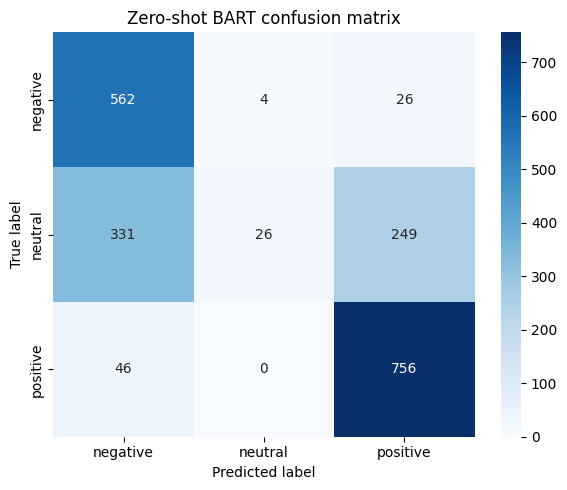

In [14]:
# Measuring zero-shot baseline performance — F1 per class and overall
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("ZERO-SHOT BASELINE RESULTS")
print("=" * 50)
print(classification_report(
    test_sample['sentiment'],
    test_sample['zero_shot_pred'],
    target_names=['negative', 'neutral', 'positive']
))

# Confusion matrix
cm = confusion_matrix(
    test_sample['sentiment'],
    test_sample['zero_shot_pred'],
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Zero-shot BART confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

PART B : Fine Tuning DistilBERT

Tokenization converts raw text into integer sequences DistilBERT understands. Max length 128 tokens balances speed vs information loss. YelpDataset wraps data in PyTorch format. We use 10k train and 2k test samples to keep Colab training under 20 minutes.

Main steps:
DistilBertTokenizer.from_pretrained(...)
loads the pretrained tokenizer that converts text into tokens (numbers) understood by DistilBERT.
YelpDataset(Dataset)
creates a custom dataset class for handling text and labels.

Inside the dataset class:

__len__()
returns the total number of samples.
__getitem__(idx)
processes one review at a time:
tokenizes the review text
truncates text to 128 tokens for faster training
pads shorter reviews to fixed length
creates:
input_ids → token IDs
attention_mask → tells model which tokens are real vs padding
label → sentiment class as tensor

Tokenizer settings:

padding='max_length' → all inputs become same length
truncation=True → cuts overly long reviews
return_tensors='pt' → returns PyTorch tensors

In [15]:
# Tokenizing text into input IDs and attention masks that DistilBERT expects
# Truncating at 128 tokens — shorter than max 512 but much faster to train on Colab
from transformers import DistilBertTokenizer
from torch.utils.data import Dataset

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class YelpDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Use 10k train, 2k test to keep Colab training time under 20 mins
train_sample = train_df.sample(10000, random_state=42)
test_sample_bert = test_df.sample(2000, random_state=42)

train_dataset = YelpDataset(
    train_sample['clean_text'].tolist(),
    train_sample['label'].tolist(),
    tokenizer
)
test_dataset = YelpDataset(
    test_sample_bert['clean_text'].tolist(),
    test_sample_bert['label'].tolist(),
    tokenizer
)

print(f"Train dataset: {len(train_dataset):,} samples")
print(f"Test dataset:  {len(test_dataset):,} samples")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train dataset: 10,000 samples
Test dataset:  2,000 samples


In [16]:
# Loading pretrained DistilBERT and attaching a 3-class classification head on top
from transformers import DistilBertForSequenceClassification
from torch.utils.data import DataLoader
import torch

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model loaded on {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda
Parameters: 66,955,779


In this step, we fine-tune the pretrained DistilBERT model for sentiment classification using the Yelp review dataset. The data is loaded in batches using PyTorch DataLoaders, and the model is trained for 3 epochs using the AdamW optimizer with weight decay regularization and a linear learning rate scheduler with warmup. During each training step, the model performs a forward pass to compute predictions and loss, followed by backpropagation to update the model weights. Gradient clipping is also applied to stabilize training. Finally, the average training loss for each epoch is recorded and plotted to monitor the learning progress and detect possible overfitting.

In [17]:
print(device)

cuda


Epoch 1/3: 100%|██████████| 313/313 [02:02<00:00,  2.56it/s]


Epoch 1 avg loss: 0.7163


Epoch 2/3: 100%|██████████| 313/313 [02:01<00:00,  2.58it/s]


Epoch 2 avg loss: 0.4818


Epoch 3/3: 100%|██████████| 313/313 [02:01<00:00,  2.58it/s]

Epoch 3 avg loss: 0.3850


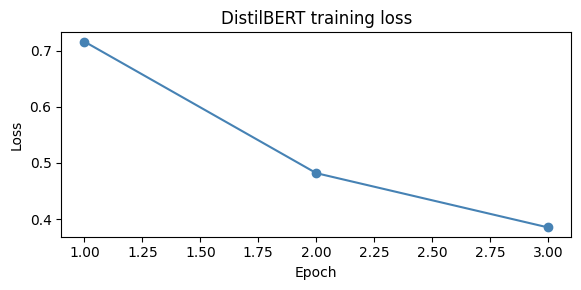

In [18]:
# Fine-tuning DistilBERT for 3 epochs — tracking loss each epoch to detect overfitting
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

train_losses = []

for epoch in range(3):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/3"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} avg loss: {avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(6, 3))
plt.plot(range(1, 4), train_losses, marker='o', color='steelblue')
plt.title('DistilBERT training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [19]:
print(device)

cuda


Evaluating: 100%|██████████| 63/63 [00:08<00:00,  7.41it/s]


FINE-TUNED DISTILBERT RESULTS
              precision    recall  f1-score   support

    negative       0.81      0.79      0.80       592
     neutral       0.67      0.67      0.67       606
    positive       0.85      0.87      0.86       802

    accuracy                           0.78      2000
   macro avg       0.78      0.77      0.78      2000
weighted avg       0.78      0.78      0.78      2000



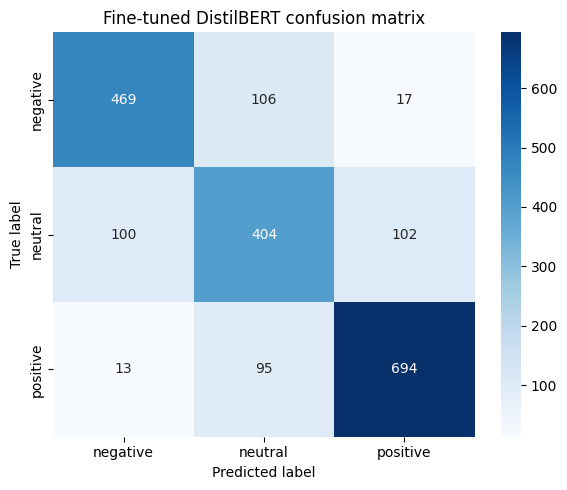

In [20]:
# Evaluating fine-tuned model and comparing directly against zero-shot baseline
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

pred_labels = [id2label[p] for p in all_preds]
true_labels = [id2label[l] for l in all_labels]

print("FINE-TUNED DISTILBERT RESULTS")
print("=" * 50)
print(classification_report(true_labels, pred_labels,
      target_names=['negative', 'neutral', 'positive']))

cm = confusion_matrix(true_labels, pred_labels,
                      labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Fine-tuned DistilBERT confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [21]:
# Final comparison table
from sklearn.metrics import f1_score

zero_shot_f1 = f1_score(
    test_sample['sentiment'],
    test_sample['zero_shot_pred'],
    average='weighted'
)

distilbert_f1 = f1_score(true_labels, pred_labels, average='weighted')

print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"{'Model':<25} {'Weighted F1':>12}")
print("-" * 38)
print(f"{'Zero-shot BART':<25} {zero_shot_f1:>12.3f}")
print(f"{'Fine-tuned DistilBERT':<25} {distilbert_f1:>12.3f}")
print("=" * 50)
print(f"\nImprovement from fine-tuning: +{(distilbert_f1 - zero_shot_f1):.3f} F1")

MODEL COMPARISON SUMMARY
Model                      Weighted F1
--------------------------------------
Zero-shot BART                   0.573
Fine-tuned DistilBERT            0.783

Improvement from fine-tuning: +0.210 F1


In [23]:
# Saving fine-tuned model and tokenizer to Drive so we can load it in the Streamlit app later
save_path = '/content/drive/MyDrive/yelp_NLP/distilbert_sentiment'
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/yelp_NLP/distilbert_sentiment
